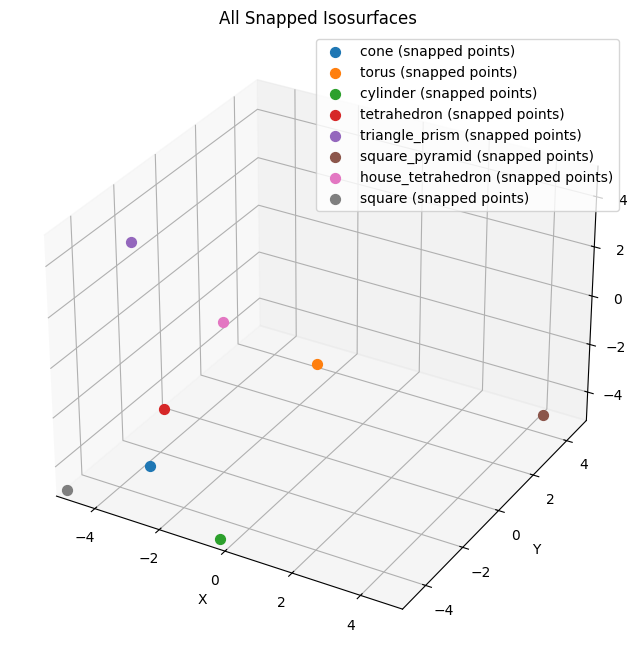

All snapped points plotted successfully.


In [7]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd

# Define the implicit functions
functions = {
    "cone": "abs(sp.sqrt(x**2 + y**2) + 2*z) + sp.sqrt(x**2 + y**2) - 3",
    "torus": "(sp.sqrt(x**2 + y**2) - 2)**2 + z**2 - 3",
    "cylinder": "abs(sp.sqrt(x**2 + y**2) - z) + abs(sp.sqrt(x**2 + y**2) + z) - 6",
    "tetrahedron": "abs(abs(abs(x) + 2*y) + abs(x) + 2*z) + abs(abs(x) + 2*y) + abs(x) - 3",
    "triangle_prism": "abs(abs(abs(x) + 2*y) + abs(x) - z) + abs(abs(abs(x) + 2*y) + abs(x) + z) - 2",
    "square_pyramid": "abs(abs(x - y) + abs(x + y) + 3*z) + abs(x - y) + abs(x + y) - 2",
    "house_tetrahedron": "abs(abs(abs(x) - y) + abs(x) + abs(y) + 3*z) + abs(abs(abs(x) - y) + abs(x) + abs(y) - z) - 2",
    "square": "abs(abs(x - y) + abs(x + y) - 2*z) + abs(abs(x - y) + abs(x + y) + 2*z) - 5",
}

# Set up the grid for numerical evaluation
def generate_grid(resolution=50, range_val=5):
    x = np.linspace(-range_val, range_val, resolution)
    y = np.linspace(-range_val, range_val, resolution)
    z = np.linspace(-range_val, range_val, resolution)
    return np.meshgrid(x, y, z)

# Snap modes
snap_modes = ["ENDpoint", "MIDpoint", "CENter", "Geometric CEnter", "NODe", "QUAdrant", "INTersection", "PERpendicular", "TANgent", "NEArest"]

# Implement snapping functions
def snap_to_mode(x, y, z, values, mode):
    # Calculate the distance between the point and the isosurface
    dist = np.abs(values)  # Distance from the surface (isosurface)

    if mode == "ENDpoint":
        # Snap to the closest endpoint (simplified as closest grid point)
        min_idx = np.argmin(dist)
        return x.flat[min_idx], y.flat[min_idx], z.flat[min_idx]

    elif mode == "MIDpoint":
        # Snap to the midpoint (average coordinates of all points)
        return np.mean(x), np.mean(y), np.mean(z)

    elif mode == "CENter":
        # Snap to the geometric center (centroid of points)
        return np.mean(x), np.mean(y), np.mean(z)

    elif mode == "Geometric CEnter":
        # Center using bounding box (simple approach)
        return (np.min(x) + np.max(x)) / 2, (np.min(y) + np.max(y)) / 2, (np.min(z) + np.max(z)) / 2

    elif mode == "NODe":
        # Snap to the nearest node (grid point)
        min_idx = np.argmin(dist)
        return x.flat[min_idx], y.flat[min_idx], z.flat[min_idx]

    elif mode == "QUAdrant":
        # Divide space into quadrants and snap
        quadrant = np.sign(x) * 2 + np.sign(y) * 1 + np.sign(z) * 0.5
        return x.flat[np.argmin(quadrant)], y.flat[np.argmin(quadrant)], z.flat[np.argmin(quadrant)]

    elif mode == "INTersection":
        # Snap to intersection points (simulated by nearest points)
        return np.mean(x), np.mean(y), np.mean(z)

    elif mode == "PERpendicular":
        # Use gradient to compute perpendicular snap
        gradient_x = np.gradient(values, axis=0)
        gradient_y = np.gradient(values, axis=1)
        gradient_z = np.gradient(values, axis=2)

        # Perpendicular snap based on gradient
        grad_magnitude = np.sqrt(gradient_x**2 + gradient_y**2 + gradient_z**2)
        min_idx = np.argmin(grad_magnitude)
        return x.flat[min_idx], y.flat[min_idx], z.flat[min_idx]

    elif mode == "TANgent":
        # Approximate tangent by gradient
        gradient_x = np.gradient(values, axis=0)
        gradient_y = np.gradient(values, axis=1)
        gradient_z = np.gradient(values, axis=2)

        # Find point with maximum gradient magnitude
        grad_magnitude = np.sqrt(gradient_x**2 + gradient_y**2 + gradient_z**2)
        min_idx = np.argmin(grad_magnitude)
        return x.flat[min_idx], y.flat[min_idx], z.flat[min_idx]

    elif mode == "NEArest":
        # Snap to nearest point on the surface
        min_idx = np.argmin(dist)
        return x.flat[min_idx], y.flat[min_idx], z.flat[min_idx]

    return x, y, z

# Evaluate the function and apply snapping
def evaluate_function(func, grid, mode):
    x, y, z = grid
    func_sympy = sp.sympify(func.replace("sp.", ""))

    func_lambdified = sp.lambdify((sp.symbols('x'), sp.symbols('y'), sp.symbols('z')), func_sympy, modules="numpy")
    values = func_lambdified(x, y, z)

    # Snap the points to the specified mode
    snapped_x, snapped_y, snapped_z = snap_to_mode(x, y, z, values, mode)

    # Find the isosurface points (where the function is close to zero)
    isosurface_points = np.where(np.abs(values) < 0.1)

    return snapped_x, snapped_y, snapped_z, x[isosurface_points], y[isosurface_points], z[isosurface_points]

# Plot the points using matplotlib with red points and larger size
def plot_points_all(functions_data):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for name, (snapped_x, snapped_y, snapped_z) in functions_data.items():
        ax.scatter(snapped_x, snapped_y, snapped_z, s=50, label=f'{name} (snapped points)', marker='o')

    ax.set_title("All Snapped Isosurfaces")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()

    # Set the limits to ensure all points are visible
    ax.set_xlim([-5, 5])
    ax.set_ylim([-5, 5])
    ax.set_zlim([-5, 5])

    plt.show()

# Main
if __name__ == "__main__":
    resolution = 20  # Adjust the resolution for better performance or accuracy
    range_val = 5    # Range of x, y, z
    grid = generate_grid(resolution, range_val)
    snap_mode = "TANgent"  # Example snap mode

    functions_data = {}

    for name, func in functions.items():
        # Evaluate and snap points
        snapped_x, snapped_y, snapped_z, x, y, z = evaluate_function(func, grid, snap_mode)

        # Store the snapped points for plotting
        functions_data[name] = (snapped_x, snapped_y, snapped_z)

    # Plot all snapped points together
    plot_points_all(functions_data)

    print("All snapped points plotted successfully.")


In [ ]:
https://help.autodesk.com/view/ACD/2025/ENU/?guid=GUID-CF5780AD-D1AB-4526-9608-83D7952749E7

In [10]:
import numpy as np
import sympy as sp
import random

# Define the basic geometric equations
geometric_functions = {
    "cone": "abs(sqrt(x**2 + y**2) + 2*z) + sqrt(x**2 + y**2) - 3",
    "torus": "(sqrt(x**2 + y**2) - 2)**2 + z**2 - 3",
    "sphere": "x**2 + y**2 + z**2 - 9",
    "cylinder": "abs(sqrt(x**2 + y**2) - z) + abs(sqrt(x**2 + y**2) + z) - 6",
    "square_pyramid": "abs(abs(x - y) + abs(x + y) + 3*z) + abs(x - y) + abs(x + y) - 2",
}

# Define symbolic variables
x, y, z = sp.symbols('x y z')

# Function to apply geometric transformations (translation, rotation, scaling)
def apply_transformation(func, translate=(0, 0, 0), scale=(1, 1, 1), rotate=None):
    # Apply translation by replacing x, y, z
    func_transformed = func.subs({'x': x + translate[0], 'y': y + translate[1], 'z': z + translate[2]})

    # Apply scaling by scaling the variables
    func_transformed = func_transformed.subs({'x': x * scale[0], 'y': y * scale[1], 'z': z * scale[2]})

    # Apply rotation if specified
    if rotate:
        # Rotation matrices for 3D space (around the X, Y, Z axes)
        theta_x, theta_y, theta_z = rotate
        rotation_matrix_x = np.array([
            [1, 0, 0],
            [0, np.cos(theta_x), -np.sin(theta_x)],
            [0, np.sin(theta_x), np.cos(theta_x)],
        ])
        rotation_matrix_y = np.array([
            [np.cos(theta_y), 0, np.sin(theta_y)],
            [0, 1, 0],
            [-np.sin(theta_y), 0, np.cos(theta_y)],
        ])
        rotation_matrix_z = np.array([
            [np.cos(theta_z), -np.sin(theta_z), 0],
            [np.sin(theta_z), np.cos(theta_z), 0],
            [0, 0, 1],
        ])

        # Combine rotations
        rotation_matrix = np.dot(np.dot(rotation_matrix_z, rotation_matrix_y), rotation_matrix_x)

        # Apply the rotation to the equation
        rotated_func = func_transformed.subs({'x': rotation_matrix[0, 0]*x + rotation_matrix[0, 1]*y + rotation_matrix[0, 2]*z,
                                              'y': rotation_matrix[1, 0]*x + rotation_matrix[1, 1]*y + rotation_matrix[1, 2]*z,
                                              'z': rotation_matrix[2, 0]*x + rotation_matrix[2, 1]*y + rotation_matrix[2, 2]*z})
        return rotated_func
    return func_transformed

# Randomly generate transformations (translation, scaling, rotation)
def random_transformation():
    translate = (random.uniform(-5, 5), random.uniform(-5, 5), random.uniform(-5, 5))
    scale = (random.uniform(0.5, 2), random.uniform(0.5, 2), random.uniform(0.5, 2))
    rotate = (random.uniform(0, np.pi), random.uniform(0, np.pi), random.uniform(0, np.pi))  # Random angles
    return translate, scale, rotate

# Function to generate random equations with transformations and output wxMaxima format
def generate_random_equations():
    equations = []
    for name, func_str in geometric_functions.items():
        func = sp.sympify(func_str)

        # Apply random transformation
        translate, scale, rotate = random_transformation()
        transformed_func = apply_transformation(func, translate, scale, rotate)

        # Generate wxMaxima format string
        transformed_func_str = str(transformed_func)
        equations.append(f"/* {name} transformed equation */: {transformed_func_str}")

    return equations

# Function to format the output in wxMaxima style
def output_to_wxmaxima(equations):
    wxmaxima_output = "/* Randomly transformed equations in wxMaxima format */\n"
    wxmaxima_output += "\n".join(equations)
    return wxmaxima_output

# Generate and output the equations
random_equations = generate_random_equations()
wxmaxima_output = output_to_wxmaxima(random_equations)

# Print wxMaxima output
print(wxmaxima_output)


/* Randomly transformed equations in wxMaxima format */
/* cone transformed equation */: 1.02343122887795*sqrt((0.704382338692554*x + y - 0.320066667713576*z + 0.170303641699701)**2 + 0.921148711422623*(x - 0.391109109503521*y + 0.561453750831826*z - 0.629217856666273)**2) + Abs(-0.362824736065457*x + 1.26550394514375*y + 3.41771354047795*z + 1.02343122887795*sqrt((0.704382338692554*x + y - 0.320066667713576*z + 0.170303641699701)**2 + 0.921148711422623*(x - 0.391109109503521*y + 0.561453750831826*z - 0.629217856666273)**2) + 6.03491864068596) - 3
/* torus transformed equation */: 10.269010196113*(sqrt((-0.272141744832112*x - 0.0554379138692696*y + 0.114300888409597*z + 1)**2 + 0.297549807368853*(-0.150502643398075*x + 0.358087048223843*y - 0.0209090286954965*z - 1)**2) - 0.624116555747209)**2 + 5.88565242920317*(-0.523450876822277*x - 0.283334716574301*y + 0.206619349785809*z + 1)**2 - 3
/* sphere transformed equation */: 5.87996820260793*(-0.605280251646449*x + 0.163508131666766*y + 